In [1]:
import pickle
import numpy as np
from src.linear_correlations import CorrelationGenerator

MAIN_SEED = 42 # SHOULD MATCH THE ONE USED IN THE EXPERIMENTS
np.random.seed(MAIN_SEED)

# Preparation

## Simulate Limit Model

In [2]:
d_in = 3
d_out = 3

N = 1

x_scale = 0.8
x_true = np.random.randn(d_in)
x_true = x_scale*(x_true/np.linalg.norm(x_true))

A_true = np.random.randn(d_out, d_in)
noise_level = 0.05
y_true = A_true @ x_true + noise_level * np.random.randn(d_out)

In [3]:
x_true, y_true, A_true

(array([ 0.48000164, -0.13361224,  0.62589632]),
 array([ 0.62789524,  0.26597976, -0.05539644]),
 array([[ 1.52302986, -0.23415337, -0.23413696],
        [ 1.57921282,  0.76743473, -0.46947439],
        [ 0.54256004, -0.46341769, -0.46572975]]))

In [4]:
K = 15
eta_0 = 0.1

In [5]:
infinite_model = CorrelationGenerator(
    x=x_true,
    y=y_true,
    sigma_u=1, 
    sigma_v=1, 
    a=1, 
    eta_u=eta_0, 
    eta_v=eta_0, 
    sigma_we=1, 
    sigma_wu=1,
    K=K,
    num_s=100
    )

In [6]:
result = infinite_model.run()

Running step 1/15
Running H_equation
Running xi_H_equation
Setting f_k and loss gradient
Running B_equation
Running xi_B_equation
Running diag_Gamma_equations
Running fill_MF_MG
Running fill_A
Running fill_W
Running step 2/15
Running H_equation
Running xi_H_equation
Setting f_k and loss gradient
Running B_equation
Running xi_B_equation
Running diag_Gamma_equations
Running fill_MF_MG
Running fill_A
Running fill_W
Running step 3/15
Running H_equation
Running xi_H_equation
Setting f_k and loss gradient
Running B_equation
Running xi_B_equation
Running diag_Gamma_equations
Running fill_MF_MG
Running fill_A
Running fill_W
Running step 4/15
Running H_equation
Running xi_H_equation
Setting f_k and loss gradient
Running B_equation
Running xi_B_equation
Running diag_Gamma_equations
Running fill_MF_MG
Running fill_A
Running fill_W
Running step 5/15
Running H_equation
Running xi_H_equation
Setting f_k and loss gradient
Running B_equation
Running xi_B_equation
Running diag_Gamma_equations
Running f

## L, M, D ranges used in Experiments

In [7]:
n_L = 15
n_M = 15
n_D = 15
range_L = 500
range_M = 500
range_D = 500
N_reps = 5

def logspace_int(lo, hi, n):
    """Log-spaced integers (floor), matching Julia's convention."""
    return np.floor(10**(np.linspace(np.log10(lo), np.log10(hi), n))).astype(int)

Ls = logspace_int(10, range_L, n_L)
Ms = logspace_int(10, range_M, n_M)
Ds = logspace_int(10, range_D, n_D)

print("Ls:", Ls)
print("Ms:", Ms)
print("Ds:", Ds)

loop_SEED = 0

Ls: [ 10  13  17  23  30  40  53  70  93 123 163 216 285 378 499]
Ms: [ 10  13  17  23  30  40  53  70  93 123 163 216 285 378 499]
Ds: [ 10  13  17  23  30  40  53  70  93 123 163 216 285 378 499]


## Read Experiment results

In [8]:
W_SEEDs = ["A", 0, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]

In [9]:
outputs_track_list = []
loss_track_list = []
mean_hs_track_list = []
max_hs_track_list = []
mean_bs_track_list = []
max_bs_track_list = []

for W_SEED in W_SEEDs:
    with open(f"data/exp_track_rate/outputs_track_D{range_D}_L{range_L}_M{range_M}_reps{N_reps}_K{K}_loop_SEED{loop_SEED}_WSEED{W_SEED}_MAIN_SEED{MAIN_SEED}.pkl", "rb") as f:  
        outputs_track = pickle.load(f)
    with open(f"data/exp_track_rate/loss_track_D{range_D}_L{range_L}_M{range_M}_reps{N_reps}_K{K}_loop_SEED{loop_SEED}_WSEED{W_SEED}_MAIN_SEED{MAIN_SEED}.pkl", "rb") as f:   
        loss_track = pickle.load(f)
    with open(f"data/exp_track_rate/mean_hs_track_D{range_D}_L{range_L}_M{range_M}_reps{N_reps}_K{K}_loop_SEED{loop_SEED}_WSEED{W_SEED}_MAIN_SEED{MAIN_SEED}.pkl", "rb") as f:  
        mean_hs_track = pickle.load(f)
    with open(f"data/exp_track_rate/max_hs_track_D{range_D}_L{range_L}_M{range_M}_reps{N_reps}_K{K}_loop_SEED{loop_SEED}_WSEED{W_SEED}_MAIN_SEED{MAIN_SEED}.pkl", "rb") as f:  
        max_hs_track = pickle.load(f)
    with open(f"data/exp_track_rate/mean_bs_track_D{range_D}_L{range_L}_M{range_M}_reps{N_reps}_K{K}_loop_SEED{loop_SEED}_WSEED{W_SEED}_MAIN_SEED{MAIN_SEED}.pkl", "rb") as f: 
        mean_bs_track = pickle.load(f)
    with open(f"data/exp_track_rate/max_bs_track_D{range_D}_L{range_L}_M{range_M}_reps{N_reps}_K{K}_loop_SEED{loop_SEED}_WSEED{W_SEED}_MAIN_SEED{MAIN_SEED}.pkl", "rb") as f: 
        max_bs_track = pickle.load(f)
    
    outputs_track_list.append(outputs_track)
    loss_track_list.append(loss_track)
    mean_hs_track_list.append(mean_hs_track)
    max_hs_track_list.append(max_hs_track)
    mean_bs_track_list.append(mean_bs_track)
    max_bs_track_list.append(max_bs_track)
    
infinite_output = result["f"][np.newaxis, np.newaxis, np.newaxis, np.newaxis,:]
output_errs_track_list = []
for outputs_track in outputs_track_list:
    output_errs_track_list.append(np.sqrt(np.mean(np.abs(outputs_track - infinite_output)**2, axis=-1)))

/var/folders/r6/y41vjmr92m187frtv8jcv8_80000gn/T/ipykernel_40230/3847329705.py:32: RuntimeWarning: overflow encountered in square
  output_errs_track_list.append(np.sqrt(np.mean(np.abs(outputs_track - infinite_output)**2, axis=-1)))


# Plots

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def plot_scaling_summary(data, Ds, Ms, Ls, series_step=1, series_start=0, mins=None, maxs= None, overrides=None, fix_d=-1, fix_l=-1, figsize=(15, 5), output_error_plot=False):
    """
    Three-panel summary figure for RMS error scaling.

    data : np.ndarray, shape (len(Ls), len(Ms), len(Ds))

    Panel 1: error vs D, fixed L (largest), series over M
    Panel 2: error vs L, fixed D (largest), series over M
    Panel 3: error vs M, fixed D (largest), series over L

    Fits  max{ α√(D/ML),  β/√D,  γ/L }  once globally, then overlays
    the fitted curves on every panel.
    """
    Ds, Ms, Ls = np.array(Ds), np.array(Ms), np.array(Ls)

    # ------------------------------------------------------------------
    # 1. Global fit across all (L, M, D) triples
    # ------------------------------------------------------------------
    li, mi, di = np.meshgrid(np.arange(len(Ls)), np.arange(len(Ms)), np.arange(len(Ds)), indexing='ij')
    D_all = Ds[di.ravel()]
    M_all = Ms[mi.ravel()]
    L_all = Ls[li.ravel()]
    y_all = data.ravel()
    
    (minD, minM, minL) = (50, 50, 50) if mins is None else mins
    (maxD, maxM, maxL) = (10000, 10000, 10000) if maxs is None else maxs
    
    mask = (y_all > 0) & (D_all > minD) & (M_all > minM) & (L_all > minL) & (D_all < maxD) & (M_all < maxM) & (L_all < maxL)
    D_all, M_all, L_all, y_all = D_all[mask], M_all[mask], L_all[mask], y_all[mask]

    def model(_, alpha, beta, gamma):
        return np.sqrt( alpha * (np.sqrt(D_all / (M_all * L_all)))**2 + beta  * (1/ np.sqrt(D_all))**2 + gamma * (1/ L_all)**2)

    (alpha, beta, gamma), _ = curve_fit(model, None, y_all,
                                        p0=[0.85, 2.4, 0.001], bounds=(0, np.inf))

    if overrides is not None:
        alpha, beta, gamma = overrides

    def fitted_curve(D, M, L):
        return np.sqrt( alpha * (np.sqrt(D / (M * L)))**2 + beta  * (1/ np.sqrt(D))**2 + gamma * (1/ L)**2)

    Ms = Ms[:-1]
    # ------------------------------------------------------------------
    # 2. Plot
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle(
        "Forward Pass RMS error for varying ResNet shapes" if not output_error_plot else "Output RMS error for varying ResNet shapes",
        fontsize=11
    )

    prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    def get_color(i):
        return prop_cycle[i % len(prop_cycle)]

    # --- Panel 1: error vs D, fixed L[-1], series over M --------------
    ax = axes[0]
    for i, (mi, M) in enumerate(zip(range(series_start, len(Ms), series_step), Ms[series_start::series_step])):
        y = data[-1, mi, :]                          # shape (len(Ds),)
        color = get_color(i)
        ax.scatter(Ds, y, color=color, label=f"M={M:.3g}")
        ax.plot(Ds, fitted_curve(Ds, M, Ls[-1]), '--', color=color)
    ax.set(xscale='log', yscale='log', xlabel='D', ylabel='RMS Error',
           title=f'L={Ls[-1]:.3g}')
    ax.legend(fontsize='small')

    # --- Panel 2: error vs L, fixed D[-1], series over M --------------
    ax = axes[1]
    for i, (mi, M) in enumerate(zip(range(series_start, len(Ms), series_step), Ms[series_start::series_step])):
        y = data[:, mi, fix_d]                          # shape (len(Ls),)
        color = get_color(i)
        ax.scatter(Ls, y, color=color, label=f"M={M:.3g}")
        ax.plot(Ls, fitted_curve(Ds[fix_d], M, Ls), '--', color=color)
    ax.set(xscale='log', yscale='log', xlabel='L', #ylabel='RMS Error',
           title=f'D={Ds[fix_d]:.3g}')
    ax.legend(fontsize='small')

    # --- Panel 3: error vs M, fixed L[-1], series over D --------------
    ax = axes[2]
    for i, (di, D) in enumerate(zip(range(series_start, len(Ds), series_step), Ds[series_start::series_step])):
        y = data[fix_l, :-1, di]                          # shape (len(Ms),)
        color = get_color(i)
        ax.scatter(Ms, y, color=color, label=f"D={D:.3g}")
        ax.plot(Ms, fitted_curve(D, Ms, Ls[fix_l]), '--', color=color)
    ax.set(xscale='log', yscale='log', xlabel='M',
           title=f'L={Ls[fix_l]:.3g}')
    ax.legend(fontsize='small')

    fig.tight_layout()
    return fig, axes, (alpha, beta, gamma)

## Plot Max Error

In [11]:
output_errs_track = np.concatenate(max_hs_track_list)
#output_errs_track = np.concatenate(mean_hs_track_list)

output_errs_track.shape
# Remove duplicate "experiments" along the first axis (0)
unique_output_errs_track = np.unique(output_errs_track, axis=0)
print(f"Original shape: {output_errs_track.shape}")
print(f"Unique shape:   {unique_output_errs_track.shape}")

THRESHOLD = 1e3 # Removing divergent runs (numerical instability)
filtered_unique_output_errs_track = np.where(unique_output_errs_track > THRESHOLD, 0, unique_output_errs_track)

data = filtered_unique_output_errs_track.mean(axis=0) # Mean over repetitions.
id_train = 5 #3 
data=data[:, :, :, id_train]
#data = data[:, :, :, :id_train+1].max(axis=-1)
data.shape # (nL, nM, nD)

Original shape: (65, 15, 15, 15, 15)
Unique shape:   (65, 15, 15, 15, 15)


(15, 15, 15)

alpha: 0.6733887465323354, beta: 0.4371921793705387, gamma: 4.49324074468983e-16, K:5


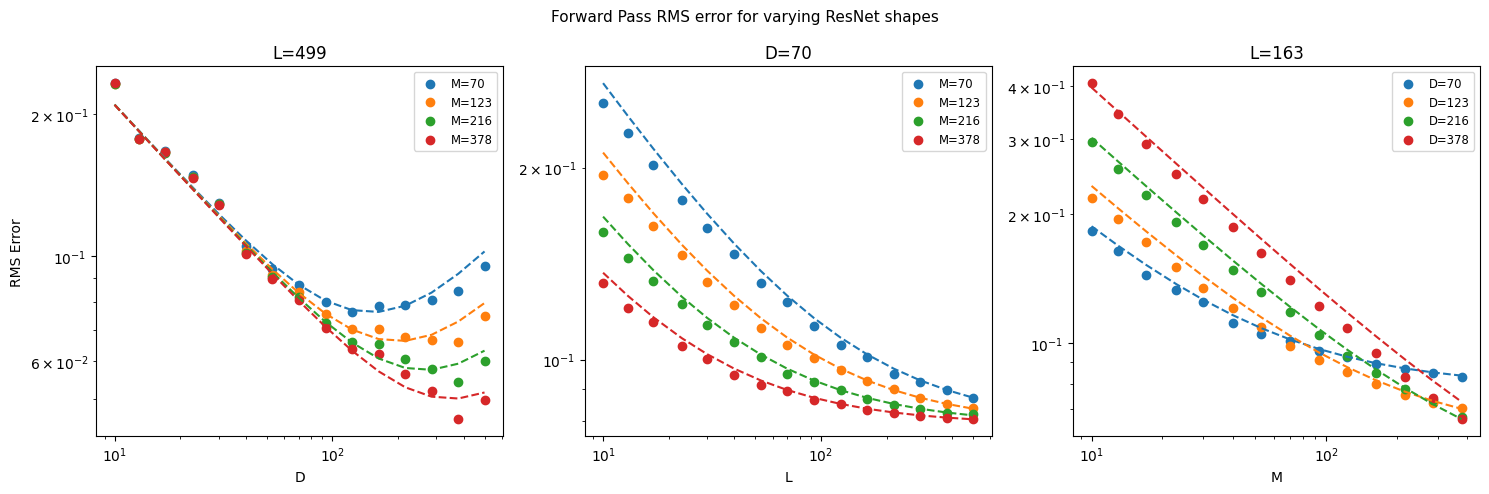

In [12]:
fig, axes, (alpha, beta, gamma) = plot_scaling_summary(data, Ds, Ms, Ls, series_step=2, series_start=7, fix_d=-8, fix_l=-5, mins=(10, 10, 50))
print(f"alpha: {alpha}, beta: {beta}, gamma: {gamma}, K:{id_train}")
plt.savefig(f"plots/scaling_K{id_train}.pdf", bbox_inches="tight")

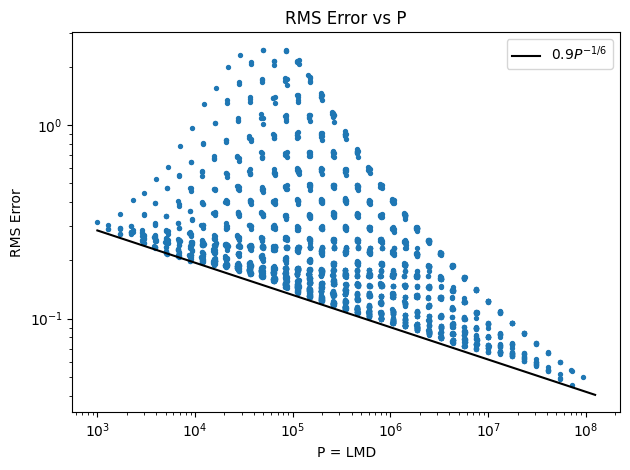

In [13]:
P = [Ls[i]*Ms[ii]*Ds[iii] for i in range(len(Ls)) for ii in range(len(Ms)) for iii in range(len(Ds))]
err = [data[i,ii,iii] for i in range(len(Ls)) for ii in range(len(Ms)) for iii in range(len(Ds))]

plt.scatter(P,err, s=8)
cst= np.sqrt( alpha**2 + beta**2 + gamma**2) +0.1
plt.plot(P, cst*np.array(P)**(-1/6), c="k", label=rf"${np.round(cst,2)}P^{{-1/6}}$")
plt.title("RMS Error vs P")
plt.xlabel("P = LMD")
plt.ylabel("RMS Error")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.savefig("plots/scalinginP.pdf", bbox_inches="tight")
plt.show()


## Plot OutputError

In [14]:
output_errs_track = np.concatenate(output_errs_track_list)
#output_errs_track = np.concatenate(mean_hs_track_list)

output_errs_track.shape
# Remove duplicate "experiments" along the first axis (0)
unique_output_errs_track = np.unique(output_errs_track, axis=0)
print(f"Original shape: {output_errs_track.shape}")
print(f"Unique shape:   {unique_output_errs_track.shape}")

THRESHOLD = 1e3 # Removeing divergent runs (numerical instability)
filtered_unique_output_errs_track = np.where(unique_output_errs_track > THRESHOLD, 0, unique_output_errs_track)

data = filtered_unique_output_errs_track.mean(axis=0) # Mean over repetitions.
id_train = 5
data_output=data[:, :, :, id_train]
#data_output=data[:, :, :, id_train:id_train+1].max(axis=-1)
print(f"Data Output Shape: {data_output.shape}") # (nL, nM, nD)

Original shape: (65, 15, 15, 15, 15)
Unique shape:   (65, 15, 15, 15, 15)
Data Output Shape: (15, 15, 15)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def plot_scaling_summary_other_rate(data, Ds, Ms, Ls, series_step=1, series_start=0, mins=None, maxs=None, fix_d=-1, fix_l=-1, figsize=(15, 5)):
    Ds, Ms, Ls = np.array(Ds), np.array(Ms), np.array(Ls)

    # ------------------------------------------------------------------
    # 1. Global fit across all (L, M, D) triples
    # ------------------------------------------------------------------
    li, mi, di = np.meshgrid(np.arange(len(Ls)), np.arange(len(Ms)), np.arange(len(Ds)), indexing='ij')
    D_all = Ds[di.ravel()]
    M_all = Ms[mi.ravel()]
    L_all = Ls[li.ravel()]
    y_all = data.ravel()
    
    (minD, minM, minL) = (50, 50, 50) if mins is None else mins
    (maxD, maxM, maxL) = (10000, 10000, 10000) if maxs is None else maxs
    
    mask = (y_all > 0) & (D_all > minD) & (M_all > minM) & (L_all > minL) & (D_all < maxD) & (M_all < maxM) & (L_all < maxL)
    D_all, M_all, L_all, y_all = D_all[mask], M_all[mask], L_all[mask], y_all[mask]

    # --- Correct model: α * D / (M * L) ---
    def model_correct(_, alpha, beta, gamma):
        return np.sqrt( alpha * (D_all / (M_all * L_all))**2 + beta  * (1/ np.sqrt(D_all))**2 ) # ignore 1/L term

    (alpha, beta, gamma), _ = curve_fit(model_correct, None, y_all,
                                        p0=[10, 2.4, 0.0001], bounds=(0, np.inf))

    def fitted_curve(D, M, L):
        return np.sqrt( alpha * (D / (M * L))**2 + beta  * (1/ np.sqrt(D))**2)

    # --- Wrong model: α * √D / √(M * L) ---
    def model_wrong(_, alpha_w, beta_w, gamma_w):
        return np.sqrt( alpha_w * (np.sqrt(D_all / (M_all * L_all)))**2 + beta_w  * (1/ np.sqrt(D_all))**2) # ignore 1/L term

    (alpha_w, beta_w, gamma_w), _ = curve_fit(model_wrong, None, y_all,
                                              p0=[10, 2.4, 0.0001], bounds=(0, np.inf))

    def fitted_curve_wrong(D, M, L):
        return np.sqrt( alpha_w * (np.sqrt(D / (M * L)))**2 + beta_w  * (1/ np.sqrt(D))**2)

    Ms = Ms[:-1]
    # ------------------------------------------------------------------
    # 2. Plot
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle(
        "Output RMS error for varying ResNet shapes",
        fontsize=11
    )

    prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    def get_color(i):
        return prop_cycle[i % len(prop_cycle)]

    WRONG_ALPHA = 0.35  # visual transparency for the wrong-scaling curves

    # --- Panel 1: error vs D, fixed L[-1], series over M --------------
    ax = axes[0]
    for i, (mi, M) in enumerate(zip(range(series_start, len(Ms), series_step), Ms[series_start::series_step])):
        last_i= len(Ms[series_start::series_step])-1
        y = data[-1, mi, :]
        color = get_color(i)
        ax.scatter(Ds, y, color=color, label=f"M={M:.3g}")
        # Correct fit
        ax.plot(Ds, fitted_curve(Ds, M, Ls[-1]), '--', color=color,
                label=r'fit: $ D/ML$' if i == last_i else None)
        # Wrong fit
        ax.plot(Ds, fitted_curve_wrong(Ds, M, Ls[-1]), ':', color=color,
                alpha=WRONG_ALPHA,
                label=r'fit: $\sqrt{D/ML}$' if i == last_i else None)
    ax.set(xscale='log', yscale='log', xlabel='D', ylabel='RMS Error',
           title=f'L={Ls[-1]:.3g}')
    ax.legend(fontsize='small')

    # --- Panel 2: error vs L, fixed D[fix_d], series over M -----------
    ax = axes[1]
    for i, (mi, M) in enumerate(zip(range(series_start, len(Ms), series_step), Ms[series_start::series_step])):
        last_i= len(Ms[series_start::series_step])-1
        y = data[:, mi, fix_d]
        color = get_color(i)
        ax.scatter(Ls, y, color=color, label=f"M={M:.3g}")
        ax.plot(Ls, fitted_curve(Ds[fix_d], M, Ls), '--', color=color,
                label=r'fit: $ D/ML$' if i == last_i else None)
        ax.plot(Ls, fitted_curve_wrong(Ds[fix_d], M, Ls), ':', color=color,
                alpha=WRONG_ALPHA,
                label=r'fit: $\sqrt{D/ML}$' if i == last_i else None)
    ax.set(xscale='log', yscale='log', xlabel='L',
           title=f'D={Ds[fix_d]:.3g}')
    ax.legend(fontsize='small')

    # --- Panel 3: error vs M, fixed L[fix_l], series over D -----------
    ax = axes[2]
    for i, (di, D) in enumerate(zip(range(series_start, len(Ds), series_step), Ds[series_start::series_step])):
        last_i= len(Ds[series_start::series_step])-1
        y = data[fix_l, :-1, di]
        color = get_color(i)
        ax.scatter(Ms, y, color=color, label=f"D={D:.3g}")
        ax.plot(Ms, fitted_curve(D, Ms, Ls[fix_l]), '--', color=color,
                label=r'fit: $D/ML$' if i == last_i else None)
        ax.plot(Ms, fitted_curve_wrong(D, Ms, Ls[fix_l]), ':', color=color,
                alpha=WRONG_ALPHA,
                label=r'fit: $\sqrt{D/ML}$' if i == last_i else None)
    ax.set(xscale='log', yscale='log', xlabel='M',
           title=f'L={Ls[fix_l]:.3g}')
    ax.legend(fontsize='small', loc="upper left")

    fig.tight_layout()
    return fig, axes, (alpha, beta, gamma), (alpha_w, beta_w, gamma_w)

alpha: 0.026467528761975702, beta: 0.2500039548999767, gamma: 0.0001, K:5
alpha_w: 0.010691071068677522, beta_w: 0.24283508744495572, gamma_w: 0.0001, K:5


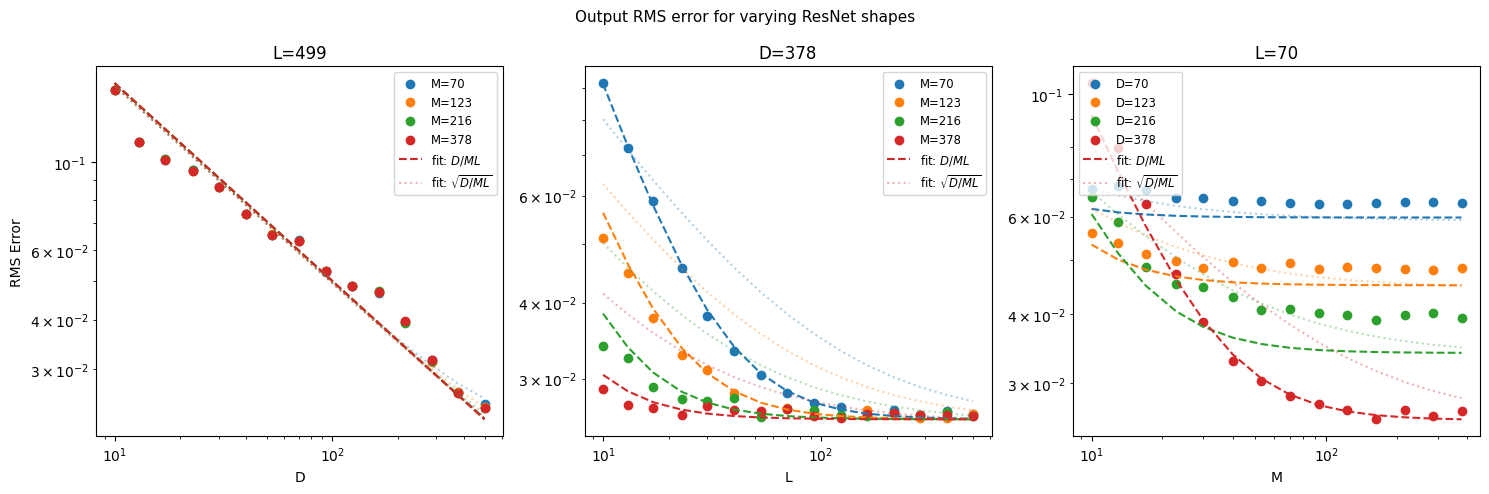

In [16]:
fig, axes, (alpha, beta, gamma), (alpha_w, beta_w, gamma_w) = plot_scaling_summary_other_rate(data_output, Ds, Ms, Ls, series_step=2, series_start=7, fix_d=-2, fix_l= -8, mins=(10,10,10), maxs=(200,1000,200))
print(f"alpha: {alpha}, beta: {beta}, gamma: {gamma}, K:{id_train}")
print(f"alpha_w: {alpha_w}, beta_w: {beta_w}, gamma_w: {gamma_w}, K:{id_train}")
plt.savefig(f"plots/scaling_K{id_train}_output.pdf", bbox_inches="tight")

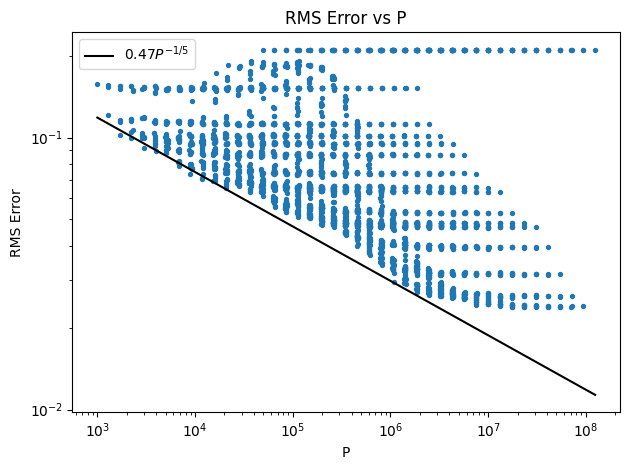

In [17]:
P = [Ls[i]*Ms[ii]*Ds[iii] for i in range(len(Ls)) for ii in range(len(Ms)) for iii in range(len(Ds))]
err = [data_output[i,ii,iii] for i in range(len(Ls)) for ii in range(len(Ms)) for iii in range(len(Ds))]

plt.scatter(P,err, s=8)
cst= np.sqrt(alpha**2 + beta**2) + 0.22
plt.plot(P, cst*np.array(P)**(-1/5), c="k", label=rf"${np.round(cst,2)}P^{{-1/5}}$")
plt.title("RMS Error vs P")
plt.xlabel("P")
plt.ylabel("RMS Error")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.savefig("plots/scalinginP_output.pdf", bbox_inches="tight")
plt.show()